In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

In [3]:
df = pd.read_csv("../data/superstore.csv", encoding="latin-1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn Names:\n", df.columns.tolist())

Rows: 9994
Columns: 21

Column Names:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [5]:
print(df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing Values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


## Missing Values
No missing values found across all 21 columns. Dataset is complete and ready for analysis.

In [6]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [7]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


## Negative profit means the company is losing money on some orders

High discounts — they discounted a product so much it sold below cost

High shipping costs — the shipping ate into the profit

Returns — some orders were returned

In [10]:
# How many ordrs have negative profit?
negative_profit_count=  df[df['Profit']<0]
print("Number of orders with negative profit:", len(negative_profit_count))
print("Percentage of orders with negative profit:", round(len(negative_profit_count)/len(df)*100, 2), "%")

#What is the total money lost ?
print("Total money lost due to negative profit orders:", round(negative_profit_count['Profit'].sum(), 2))

Number of orders with negative profit: 1871
Percentage of orders with negative profit: 18.72 %
Total money lost due to negative profit orders: -156131.29


C:\Users\DELL\AppData\Local\Temp\ipykernel_24184\3303245235.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loss_by_subcategory.values, y=loss_by_subcategory.index, palette="Reds_r")


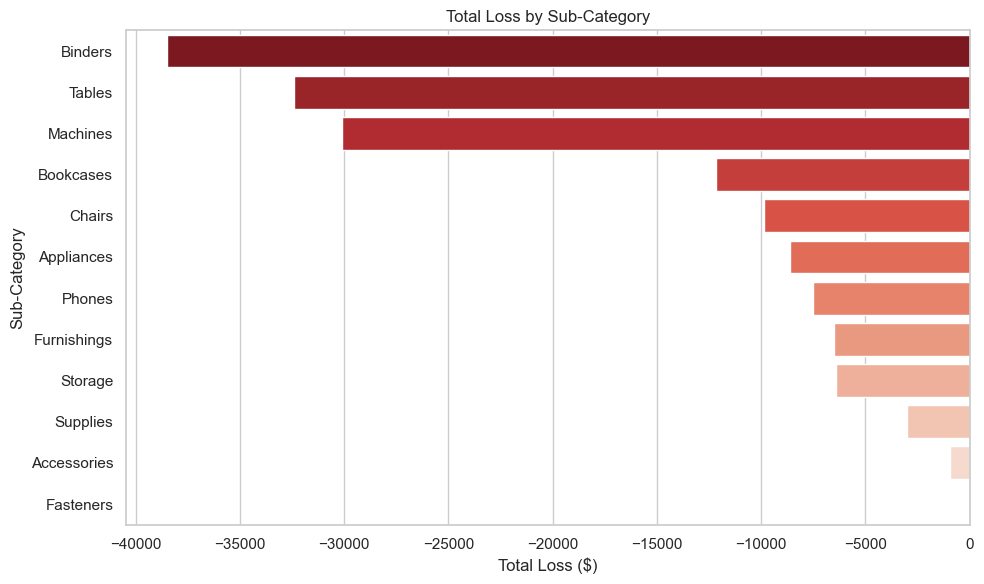

In [ ]:
#wich sub-category are causing the most losses?
loss_by_subcategory = negative_profit_count.groupby('Sub-Category')['Profit'].sum().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=loss_by_subcategory.values, y=loss_by_subcategory.index, palette="Reds_r")
plt.title("Total Loss by Sub-Category")
plt.xlabel("Total Loss ($)")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

#  Binders are a very common office supply that gets heavily discounted

In [24]:
# Investigate Binders specifically
binders = df[df['Sub-Category'] == 'Binders']

print("Total Binders orders:", len(binders))
print("Profitable orders:", round(len(binders[binders['Profit'] > 0])/len(binders) * 100, 2), "%")
print("Loss-making orders:", round(len(binders[binders['Profit'] < 0])/len(binders) * 100, 2), "%")
print("Total Profit from Binders: $", round(binders['Profit'].sum(), 2))
print("Average Discount on Binders:", round(binders['Discount'].mean() * 100, 2), "%")

Total Binders orders: 1523
Profitable orders: 59.75 %
Loss-making orders: 40.25 %
Total Profit from Binders: $ 30221.76
Average Discount on Binders: 37.23 %


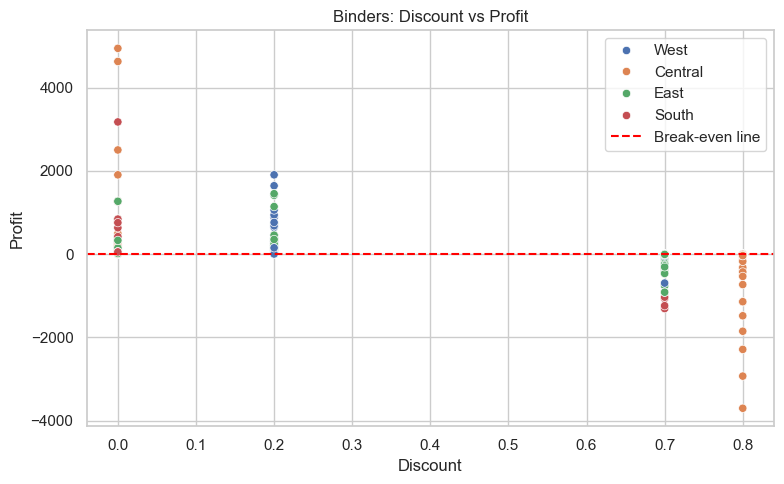

In [25]:
# Does higher discount = more loss in Binders?
plt.figure(figsize=(8,5))
sns.scatterplot(data=binders, x='Discount', y='Profit', hue='Region')
plt.title("Binders: Discount vs Profit")
plt.axhline(0, color='red', linestyle='--', label='Break-even line')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_24184\3131796911.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette="Blues_d", ax=axe[0])
C:\Users\DELL\AppData\Local\Temp\ipykernel_24184\3131796911.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_profit.index, y=category_profit.values, palette="Reds_d", ax=axe[1])


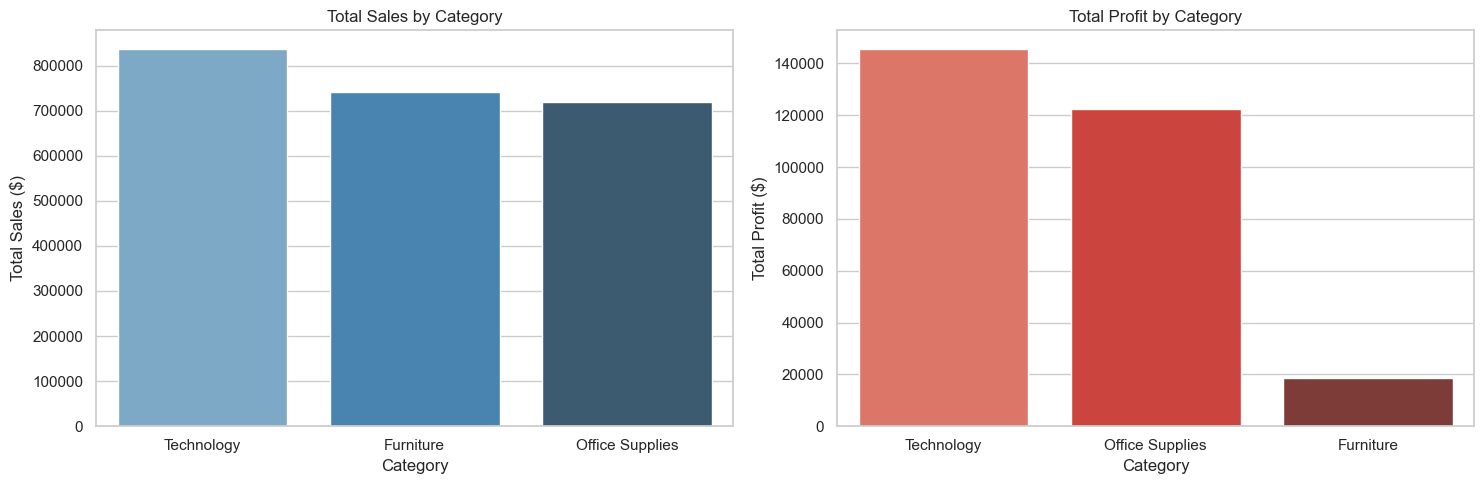

In [26]:
# Compare Sales and Profit by Category
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
fig , axe = plt.subplots(1,2, figsize=(15,5))
sns.barplot(x=category_sales.index, y=category_sales.values, palette="Blues_d", ax=axe[0])
axe[0].set_title("Total Sales by Category")
axe[0].set_ylabel("Total Sales ($)")
sns.barplot(x=category_profit.index, y=category_profit.values, palette="Reds_d", ax=axe[1])
axe[1].set_title("Total Profit by Category")
axe[1].set_ylabel("Total Profit ($)")
plt.tight_layout()
plt.show()


In [27]:
# Profit margin by category (profit as % of sales)
category_margin = (df.groupby('Category')['Profit'].sum() / 
                   df.groupby('Category')['Sales'].sum() * 100).round(2)

print("Profit Margin by Category:")
print(category_margin.sort_values(ascending=False) )

Profit Margin by Category:
Category
Technology         17.40
Office Supplies    17.04
Furniture           2.49
dtype: float64


## Key Insight — Profit Margin by Category

| Category | Profit Margin |
|---|---|
| Technology | 17.40% |
| Office Supplies | 17.04% |
| Furniture | 2.49% |

**Finding:** Furniture has the same sales volume as Office Supplies but earns 7x less margin.
The company is investing significant effort into Furniture sales with almost no return.

**Recommendation:** Investigate Furniture discounting strategy — particularly the Tables
and Bookcases sub-categories which are likely the main drivers of this low margin.

C:\Users\DELL\AppData\Local\Temp\ipykernel_24184\1510218636.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette="Greens_d", ax=axe[0])
C:\Users\DELL\AppData\Local\Temp\ipykernel_24184\1510218636.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_profit.index, y=region_profit.values, palette="Oranges_d", ax=axe[1])


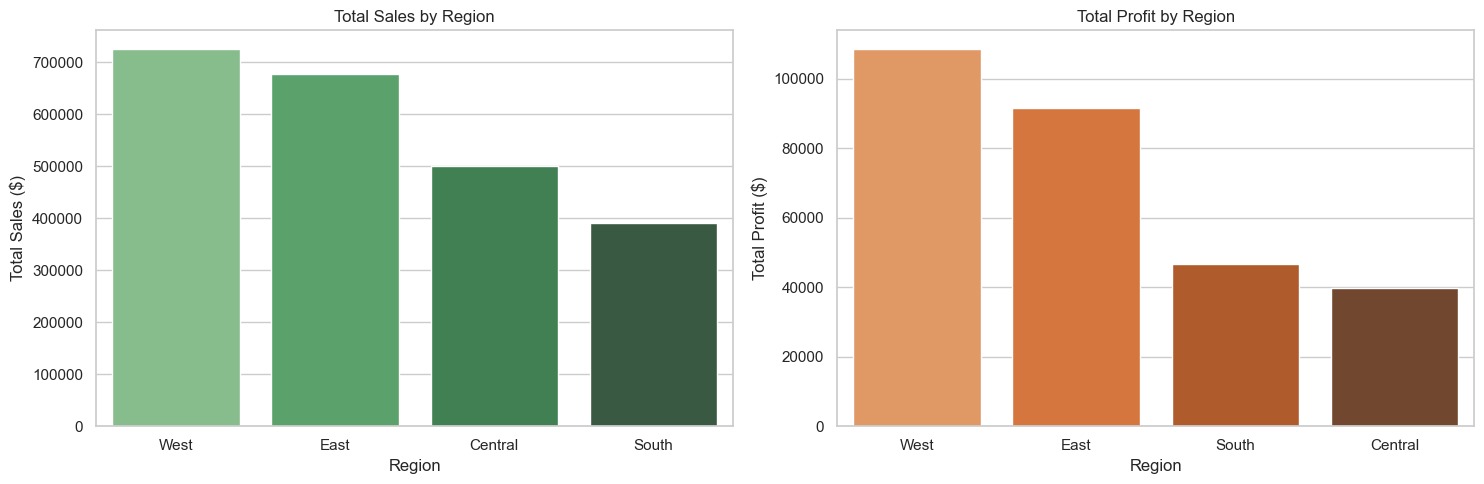

In [28]:
# Sales and profit by region
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
fig , axe = plt.subplots(1,2, figsize=(15,5))
sns.barplot(x=region_sales.index, y=region_sales.values, palette="Greens_d", ax=axe[0])
axe[0].set_title("Total Sales by Region")
axe[0].set_ylabel("Total Sales ($)")
sns.barplot(x=region_profit.index, y=region_profit.values, palette="Oranges_d", ax=axe[1])
axe[1].set_title("Total Profit by Region")
axe[1].set_ylabel("Total Profit ($)")
plt.tight_layout()
plt.show()

In [29]:
# Profit margin by category (profit as % of sales)
category_margin = (df.groupby('Region')['Profit'].sum() / 
                   df.groupby('Region')['Sales'].sum() * 100).round(2)

print("Profit Margin by Region:")
print(category_margin.sort_values(ascending=False) )

Profit Margin by Region:
Region
West       14.94
East       13.48
South      11.93
Central     7.92
dtype: float64


## Key Insight — Profit Margin by Region

| Region | Profit Margin |
|---|---|
| West | 14.94% |
| East | 13.48% |
| South | 11.93% |
| Central | 7.92% |

**Finding:** The Central region has the weakest profit margin — nearly half of the West region.
Despite generating significant sales, Central is the least efficient region in the business.

**Recommendation:** Investigate Central region's discounting behavior and product mix.
It likely follows the same pattern as Furniture — high discounts eroding profitability.

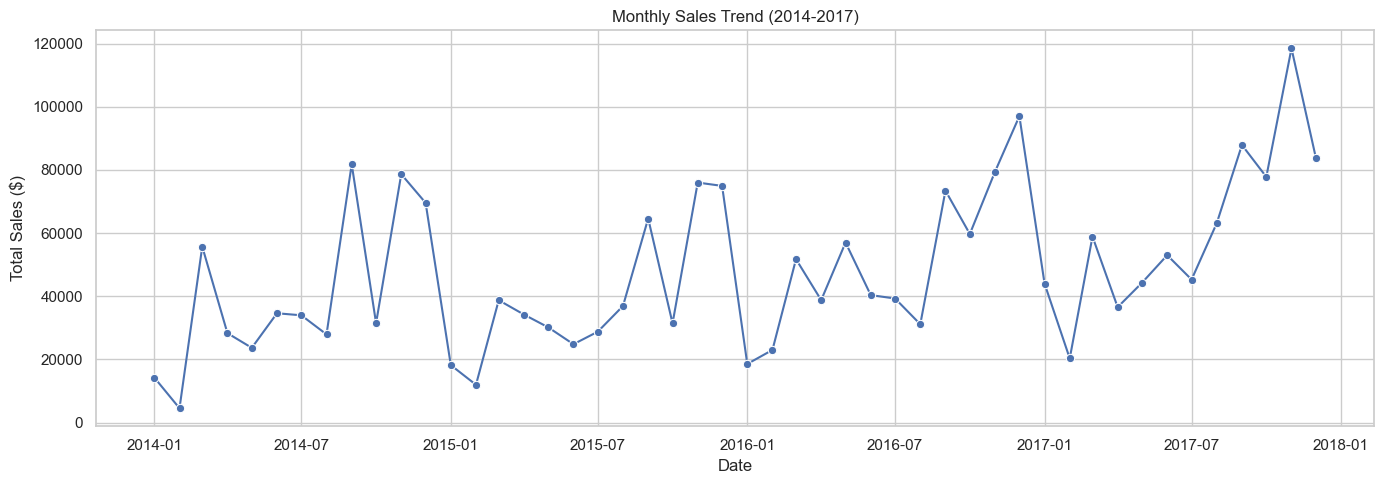

In [30]:
# Sales trend over time
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(Day=1))

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_sales, x='Date', y='Sales', marker='o')
plt.title("Monthly Sales Trend (2014-2017)")
plt.ylabel("Total Sales ($)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

## Key Insight — Sales Trend Over Time

**Growth:** Business shows consistent year-over-year growth, 
with peaks rising from ~$80k in 2014 to ~$120k in 2017.

**Seasonality:** Sales drop every January and peak every November/December.
This pattern repeats consistently across all 4 years.

**Volatility:** High month-to-month fluctuation suggests 
the business is sensitive to promotions, holidays, and bulk orders.

**Recommendation:** Plan inventory and staffing around the seasonal pattern —
increase capacity before November and manage costs during January slowdowns.

## Summary — What We Found

| Area | Finding |
|---|---|
| Data Quality | No missing values, clean dataset |
| Profitability | 18% of orders are loss-making due to excessive discounting |
| Category | Furniture has 2.49% margin vs Technology at 17.40% |
| Sub-Category | Binders are the most loss-making sub-category |
| Region | Central region is least efficient at 7.92% margin |
| Trend | Business growing YoY with consistent seasonal pattern |

**Overall Story:** The business is growing and healthy at the top level,
but a discounting problem is silently destroying profitability 
across Furniture, Binders, and the Central region.